# Orb Redemption Recommender System - For Capstone Project [Phase 2]
Author: John Eckhardt

This notebook represents **Phase 2 of the Discord Orb Redemption Recommender System capstone project**.

In Phase 1, I explored the dataset and established a baseline recommendation model. In this phase, the focus shifts toward building and comparing models that improve recommendation quality.

For simplicity, some of the deeper exploratory analysis from Phase 1 has been removed. The goal here is to:

1. Re-establish the baseline recommendation model
2. Implement additional recommendation approaches
3. Compare model performance using consistent evaluation metrics

The broader objective is to better understand user redemption behavior and explore how recommendation systems could improve item discovery within the Orb ecosystem.

## 1. Dataset Overview

The dataset consists of completed Orb redemption transactions extracted from Discord's DW. Each row represents a single completed SKU redemption event.

Key attributes include:
- `user_id`: Unique user identifier
- `sku_id`: Redeemed item identifier
- `transaction_created_at`: Redemption timestamp
- `product_line_name`: Item category
- `orbs_spent`: Orb cost of the item
- `ending_orb_balance`: User balance after redemption

This dataset forms an implicit feedback interaction log of (user, item, timestamp).

## Notebook Setup and BigQuery Connection

In [4]:
#Confirm packages are installed and conect to BQ instance
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

client = bigquery.Client(project="discord-pada-analytics")
TABLE = "discord-pada-analytics.tmp.JE_orb_redeems_02_19_2026"

In [5]:
#Create dataframe from table
query = f"""
SELECT
  transaction_created_at,
  tx_date,
  user_id,
  transaction_group_id,
  device_platform,
  sink_type_name,
  sku_id,
  sku_name_default,
  product_line_name,
  is_orbs_exclusive,
  orbs_spent,
  ending_orb_balance
FROM `{TABLE}`
"""
df = client.query(query).to_dataframe()
df.head()

,transaction_created_at,tx_date,user_id,transaction_group_id,device_platform,sink_type_name,sku_id,sku_name_default,product_line_name,is_orbs_exclusive,orbs_spent,ending_orb_balance
0,2026-01-12 15:09:04.123,2026-01-12,1431354915581730874,1460410281099526245,ios,payment,1377377712028516443,Spirit Moon,COLLECTIBLES,False,4100,430
1,2026-01-12 15:08:17.058,2026-01-12,1390638257797735354,1460410083690283123,web,payment,1343751617328975954,Mirage,COLLECTIBLES,False,4100,250
2,2026-01-12 15:07:57.913,2026-01-12,1305436285611680358,1460410003390333152,desktop,payment,1447654091390980227,Capricorn,COLLECTIBLES,False,4100,430
3,2026-01-12 15:07:39.081,2026-01-12,933125876446535857,1460409924403073076,desktop,payment,1409898408021458976,Liquid Moonlight,COLLECTIBLES,False,4100,280
4,2026-01-12 15:07:34.429,2026-01-12,1148980722646524239,1460409904895496346,desktop,payment,1282820582408192061,Scarlet Fall Foliage,COLLECTIBLES,False,4100,380


In [6]:
df.dtypes

,0
transaction_created_at,datetime64[us]
tx_date,dbdate
user_id,Int64
transaction_group_id,Int64
device_platform,object
sink_type_name,object
sku_id,Int64
sku_name_default,object
product_line_name,object
is_orbs_exclusive,boolean


In [7]:
#Convert IDs to String
df2 = df.copy()
df2["user_id"] = df["user_id"].astype("string")
df2["sku_id"] = df["sku_id"].astype("string")
df2["transaction_group_id"] = df["transaction_group_id"].astype("string")

# Ensure datetimes are proper
df2["transaction_created_at"] = pd.to_datetime(df["transaction_created_at"], utc=True, errors="coerce")
df2["tx_date"] = pd.to_datetime(df["tx_date"], errors="coerce").dt.date

# Basic numeric conversions
#df2["orbs_spent"] = pd.to_numeric(df["orbs_spent"], errors="coerce")
#df2["ending_orb_balance"] = pd.to_numeric(df["ending_orb_balance"], errors="coerce")

df2.dtypes

,0
transaction_created_at,"datetime64[us, UTC]"
tx_date,object
user_id,string[python]
transaction_group_id,string[python]
device_platform,object
sink_type_name,object
sku_id,string[python]
sku_name_default,object
product_line_name,object
is_orbs_exclusive,boolean


# EDA

### Data Quality Assessment
Before modeling, the dataset was evaluated for:

- Missing values
- Duplicate transaction records
- Invalid or non-positive Orb amounts
- Timestamp consistency

Only completed redemption transactions were included. Duplicate transaction group IDs were verified to be absent, ensuring one row per redemption event.  Much of this hygiene was completed upstream in our data engineering pipelines.

In [8]:
df2.describe()

,orbs_spent,ending_orb_balance
count,9346165.0,9346165.0
mean,2513.289205,2504.605771
std,2082.431072,4494.6285
min,120.0,0.0
25%,1400.0,350.0
50%,1400.0,750.0
75%,4100.0,2500.0
max,11000.0,92500.0


In [9]:
#Basic counts and descriptions of the data along with quality check
print("Rows:", len(df2))
print("Users:", df2["user_id"].nunique())
print("SKUs:", df2["sku_id"].nunique())
print("Min TS:", df2["transaction_created_at"].min())
print("Max TS:", df2["transaction_created_at"].max())
print("Avg redeems per user:",
      len(df2) / df2["user_id"].nunique())
print("Missingness:")
print(df2.isna().mean().sort_values(ascending=False))

Rows: 9346165
Users: 5232884
SKUs: 833
Min TS: 2026-01-01 00:00:00.069000+00:00
Max TS: 2026-02-18 23:59:59.761000+00:00
Avg redeems per user: 1.7860447508486716
Missingness:
transaction_created_at    0.0
tx_date                   0.0
user_id                   0.0
transaction_group_id      0.0
device_platform           0.0
sink_type_name            0.0
sku_id                    0.0
sku_name_default          0.0
product_line_name         0.0
is_orbs_exclusive         0.0
orbs_spent                0.0
ending_orb_balance        0.0
dtype: float64


The dataset contains 9.3 million redemption events across 5.2 million users and 833 distinct SKUs, covering the period from 1/1/2026 to 2/18/2026. This provides sufficient scale to analyze marketplace dynamics and model recommendation performance although once built, a longer lookback window could be valuable as the recommenders typically need multiple items per user to improve accuracy.

### User Behavior Analysis
Understanding user-level engagement patterns is critical for recommendation modeling. We examine redemption frequency and spending behavior to characterize the interaction structure.

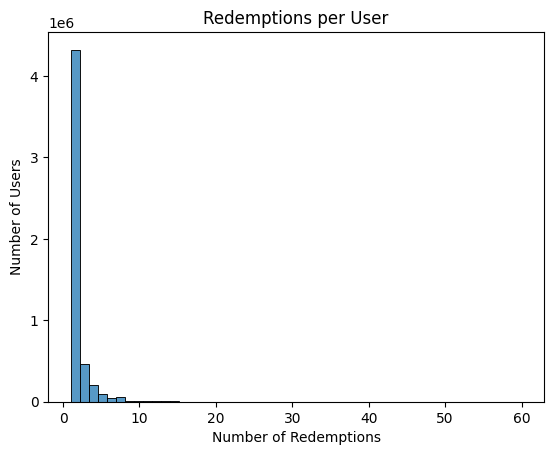

In [10]:
user_counts = df2.groupby("user_id").size()
plt.figure()
sns.histplot(user_counts, bins=50)
plt.title("Redemptions per User")
plt.xlabel("Number of Redemptions")
plt.ylabel("Number of Users")
plt.show()

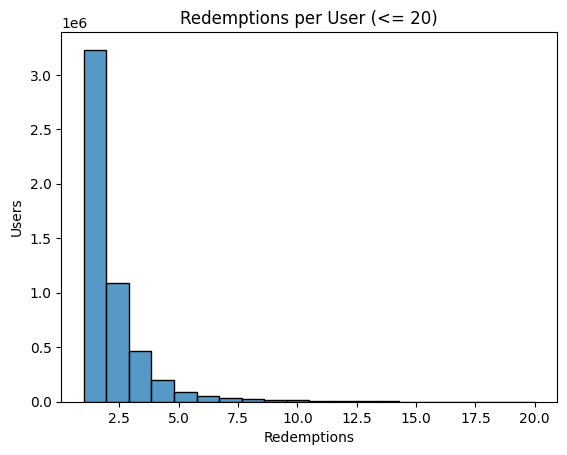

In [11]:
plt.figure()
sns.histplot(user_counts[user_counts <= 20], bins=20)
plt.title("Redemptions per User (<= 20)")
plt.xlabel("Redemptions")
plt.ylabel("Users")
plt.show()

The distribution of redemptions per user is highly skewed. Approximately 60% of users redeem only once, while a smaller subset of users exhibit repeat redemption behavior.

For modeling purposes, a next-item type prediction requires at least two events / items per user. So, we will need to restrict the final modeling data to multi-redeemer users.

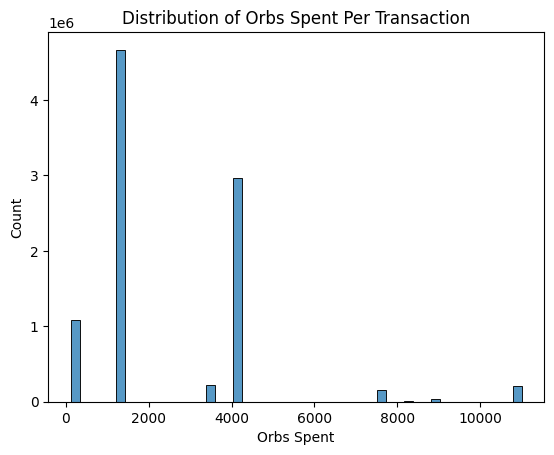

In [12]:
plt.figure()
sns.histplot(df2["orbs_spent"], bins=50)
plt.title("Distribution of Orbs Spent Per Transaction")
plt.xlabel("Orbs Spent")
plt.ylabel("Count")
plt.show()

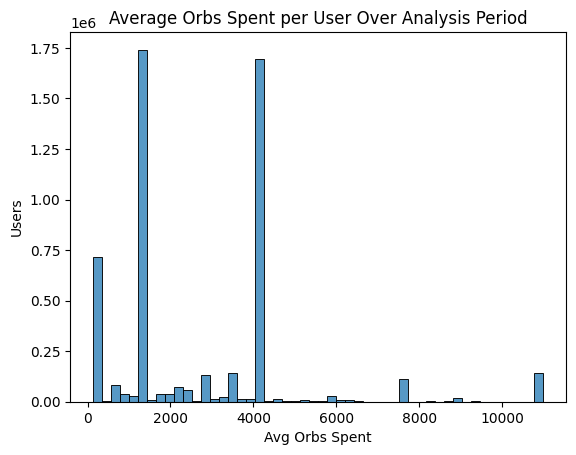

In [13]:
avg_spend_user = df2.groupby("user_id")["orbs_spent"].mean()
plt.figure()
sns.histplot(avg_spend_user, bins=50)
plt.title("Average Orbs Spent per User Over Analysis Period")
plt.xlabel("Avg Orbs Spent")
plt.ylabel("Users")
plt.show()

In [14]:
df2["orbs_spent"].quantile([0.5, 0.9, 0.95, 0.99])

,orbs_spent
0.50,1400.0
0.90,4100.0
0.95,4100.0
0.99,11000.0


The 99th percentile spend is 11k orbs, suggesting moderate tail behavior but not extreme.

### Item Behavior Analysis

Next we look at SKU popularity to determine whether the marketplace exhibits a uniform distribution of demand or is highly concentrated.

In [15]:
top_skus_table = (
    df2.groupby(["sku_id", "sku_name_default"])
       .size()
       .reset_index(name="redeem_count")
       .sort_values("redeem_count", ascending=False)
)

top_skus_table.head(20)

total_redeems = len(df2)

top_skus_table["percent_of_total"] = (
    top_skus_table["redeem_count"] / total_redeems
)

top_skus_table.head(10)

,sku_id,sku_name_default,redeem_count,percent_of_total
316,1333912750274904064,3-Day Nitro Credit,4667434,0.499396
389,1342211853484429445,Orbs Apprentice Badge,958495,0.102555
787,1462116614131548265,Nevermore,136754,0.014632
22,1144308439720394944,Angry,95557,0.010224
775,1462116613745676445,Nevermore (Midnight),90313,0.009663
60,1212569433839636530,Cat Ears,66987,0.007167
303,1333866045236314327,Angel,66609,0.007127
661,1447654090661302343,Aries,66501,0.007115
609,1427463138646954036,Magic Mists,52717,0.005640
794,1465519580016410746,Blossoming Branch,51752,0.005537


Unfortunately, SKU redemption volume is highly concentrated. The top SKU accounts for approximately 50% of total redemption events, with the second SKU contributing an additional ~10%.

This indicates a strongly head-skewed ecosystem, where a small number of items drive the majority of user purchases / engagements.

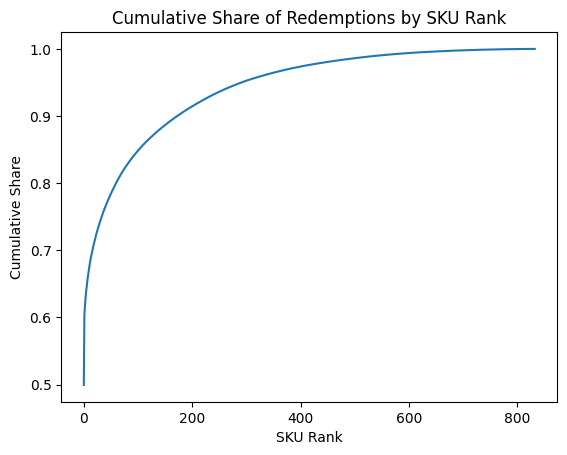

In [16]:
sku_counts = df2.groupby("sku_id").size().sort_values(ascending=False)
cum_share = sku_counts.cumsum() / sku_counts.sum()

plt.figure()
plt.plot(cum_share.values)
plt.title("Cumulative Share of Redemptions by SKU Rank")
plt.xlabel("SKU Rank")
plt.ylabel("Cumulative Share")
plt.show()

The cumulative distribution confirms significant concentration: the top 1% of SKUs account for 60% of total redemptions.

This concentration will likely influence baseline recommender performance.

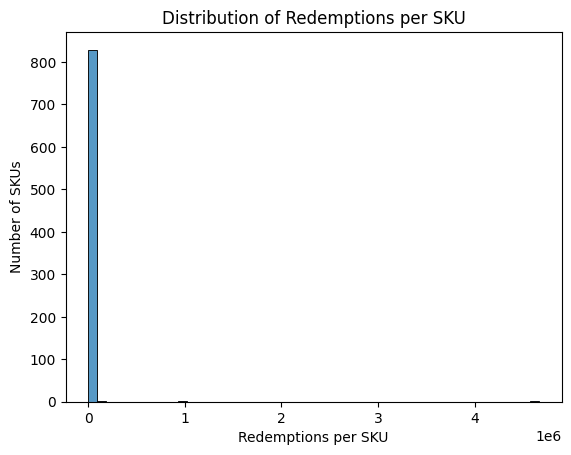

In [17]:
plt.figure()
sns.histplot(sku_counts, bins=50)
plt.title("Distribution of Redemptions per SKU")
plt.xlabel("Redemptions per SKU")
plt.ylabel("Number of SKUs")
plt.show()

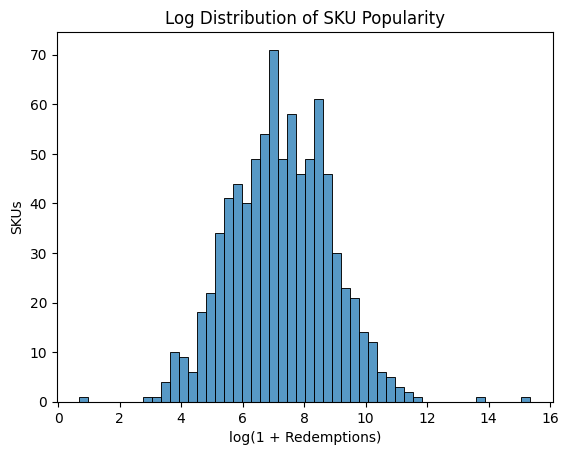

In [18]:
sku_counts = df2.groupby("sku_id").size()
plt.figure()
sns.histplot(np.log1p(sku_counts), bins=50)
plt.title("Log Distribution of SKU Popularity")
plt.xlabel("log(1 + Redemptions)")
plt.ylabel("SKUs")
plt.show()

The log-transformed SKU popularity distribution approximates a normal shape, suggesting a heavy-tailed or power-law structure in raw space.

This structure implies that a **popularity-based recommender may perform well**, though personalization may still add value beyond the dominant SKUs.

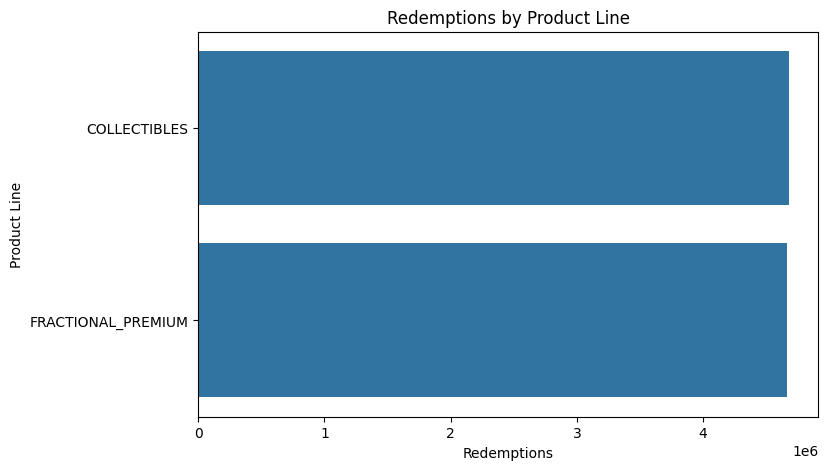

In [19]:
product_line_counts = (
    df2.groupby("product_line_name")
    .size()
    .reset_index(name="redemptions")
    .sort_values("redemptions", ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(data=product_line_counts,
            y="product_line_name",
            x="redemptions")
plt.title("Redemptions by Product Line")
plt.xlabel("Redemptions")
plt.ylabel("Product Line")
plt.show()

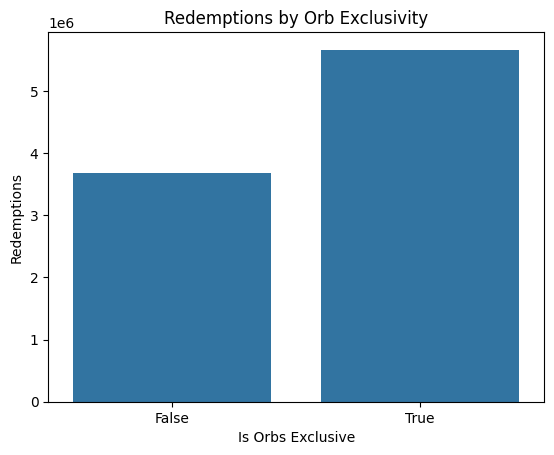

In [20]:
exclusivity = (
    df2.groupby("is_orbs_exclusive")
    .size()
    .reset_index(name="redemptions")
)

plt.figure()
sns.barplot(data=exclusivity,
            x="is_orbs_exclusive",
            y="redemptions")
plt.title("Redemptions by Orb Exclusivity")
plt.xlabel("Is Orbs Exclusive")
plt.ylabel("Redemptions")
plt.show()

### Other Insights & Correlations

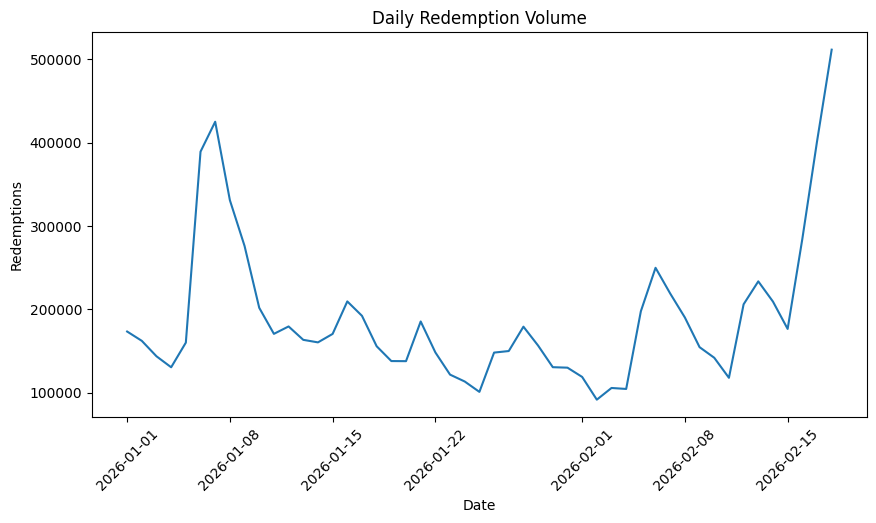

In [21]:
daily = df2.groupby("tx_date").size().reset_index(name="redemptions")

plt.figure(figsize=(10,5))
plt.plot(pd.to_datetime(daily["tx_date"]), daily["redemptions"])
plt.title("Daily Redemption Volume")
plt.xlabel("Date")
plt.ylabel("Redemptions")
plt.xticks(rotation=45)
plt.show()

Redemption volume exhibits cyclical patterns over time, suggesting day of week influences redemption likelihood. May need to consider temporal factors in the recommender optimization phase.

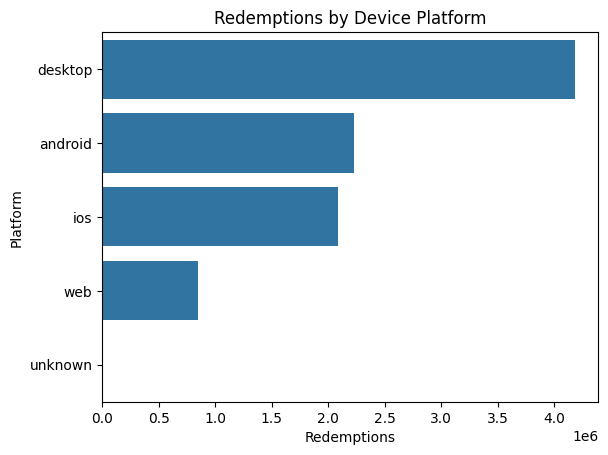

In [22]:
platform_counts = (
    df2.groupby("device_platform")
    .size()
    .reset_index(name="redemptions")
    .sort_values("redemptions", ascending=False)
)

plt.figure()
sns.barplot(data=platform_counts,
            y="device_platform",
            x="redemptions")
plt.title("Redemptions by Device Platform")
plt.xlabel("Redemptions")
plt.ylabel("Platform")
plt.show()

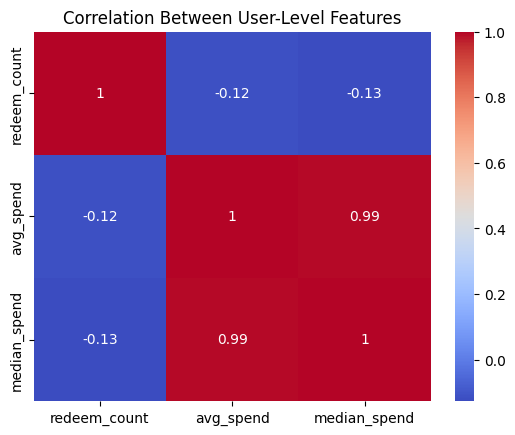

In [23]:
user_features = (
    df2.groupby("user_id")
    .agg(
        redeem_count=("transaction_group_id","count"),
        avg_spend=("orbs_spent","mean"),
        median_spend=("orbs_spent","median")
    )
)

plt.figure()
sns.heatmap(user_features.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between User-Level Features")
plt.show()

Feature Engineering Summary
- Created log-transformed spend feature for visualization
- Filtered to multi-redeemer users (≥2 interactions)
- Created user-level aggregates for modeling (redeem_count, avg_spend)

#Modeling Preparation
To evaluate recommendation performance, we restrict the modeling dataset to users with at least two redemption events. This ensures each user has observable historical behavior prior to prediction.

The modeling objective is:

Given a user's past redemption history, predict the next three SKUs they are likely to redeem next.

A popularity-based recommender is used as the baseline benchmark.

In [24]:
#From this point forward, modeling analysis will be restricted to users with at least two redemption events to enable next-item recommendation.  The dataframe will be called df2_model.
user_counts = df2.groupby("user_id").size()
valid_users = user_counts[user_counts >= 2].index
df2_model = df2[df2["user_id"].isin(valid_users)].copy()

#Baseline Recommendation Model

Baseline: Global popularity recommender.

SKUs are ranked by total redemption frequency in the training period. For each user in the test set, we recommend the top three most popular SKUs.

This establishes a non-personalized benchmark for comparison.

Our evaluation metric is hitrate for top 3 skus.

In [25]:
# Perform leave-last-interaction-out split; the last redemption per user is held out as test data.

# df2_model includes only users with >=2 redemptions
df_sorted = df2_model.sort_values(["user_id", "transaction_created_at"])

# Leave-last-interaction-out per user
last_idx = df_sorted.groupby("user_id")["transaction_created_at"].idxmax()
test = df_sorted.loc[last_idx, ["user_id", "sku_id"]].rename(columns={"sku_id": "true_sku"})
train = df_sorted.drop(index=last_idx)
# Check record counts for train and test
print("Train rows:", len(train), "| Test rows:", len(test))
print("Train users:", train["user_id"].nunique(), "| Test users:", test["user_id"].nunique())

# Global popularity from train only
sku_pop = train.groupby("sku_id").size().sort_values(ascending=False)

K = 3
topk_global = sku_pop.head(K).index.to_list()
print(f"Global Top-{K} SKUs:", topk_global)

# Recommend same Top-K to every user
test["recs"] = [topk_global] * len(test)

# HitRate@K
test["hit"] = test["true_sku"].isin(topk_global)
hitrate_at_k = test["hit"].mean()

print(f"HitRate@{K}: {hitrate_at_k:.4f}")

Train rows: 4113281 | Test rows: 2002597
Train users: 2002597 | Test users: 2002597
Global Top-3 SKUs: ['1333912750274904064', '1342211853484429445', '1462116614131548265']
HitRate@3: 0.6162


## Baseline Results Summary

Using a leave-last-interaction-out evaluation, the global popularity recommender achieved:

- HitRate@1: 0.54
- HitRate@3: 0.62
- HitRate@5: 0.64

The strong baseline performance is largely explained by the highly concentrated SKU distribution observed during exploratory analysis. Approximately 50% of all redemptions are driven by a single SKU, and over 60% are captured within the top three most popular SKUs.

As a result, a non-personalized global popularity recommender is able to correctly predict the next redemption for 62% of users when recommending only three items - which is a practical number for the surface these recommendations would show up in the application.

This establishes a strong benchmark for future personalization efforts. Any subsequent model must demonstrate incremental lift beyond this already high baseline, particularly in surfacing long-tail or user-specific items.

## Phase 2 Focus

This initial model focuses exclusively on historical redeemers and leverages a non-personalized popularity baseline. Several enhancements are planned:

**Near Term Improvements:** Using the existing redemption dataset, the following improvements are realistic and measurable for the Capstone project:

Personalized Recommendation Model
- Develop a user-personalized ranking model based on historical redemption patterns.
- Exclude previously redeemed items from recommendation lists.
- Measure lift relative to the strong global popularity baseline.

Collaborative Filtering
- Implement matrix factorization or user-item embedding approaches.
- Compare performance against the popularity baseline using HitRate@K.
- Evaluate whether personalization provides meaningful improvement beyond dominant SKUs.

Long-Tail Performance Analysis
- Re-evaluate performance excluding the top 1–3 most dominant SKUs.
- Measure whether personalization improves recommendation quality for mid-tier and long-tail items.



# Phase 2 Model Development

Phase 1 established a strong baseline recommendation model using global SKU popularity.  
In this section, I add more personalized recommendation approaches and compare them against the baseline using the same evaluation framework.

The goal is to determine whether user-specific models improve recommendation accuracy beyond a simple popularity-based benchmark.

## Model 2: Historical-Based Personalized Recommender

The first model extension adds simple personalization.

Instead of recommending the same most-popular SKUs to everyone, this model recommends items based on each user's historical redemption behavior.

For each user, SKUs are ranked by how frequently that user redeemed them in the training data. This creates a simple personalized benchmark model to compare to global recommender baseline.

In [26]:
# Build user-specific SKU redemption counts from the training set
user_sku_counts = (
    train.groupby(["user_id", "sku_id"])
    .size()
    .reset_index(name="redeem_count")
)

# Rank SKUs within each user
user_sku_counts["rank"] = user_sku_counts.groupby("user_id")["redeem_count"].rank(
    method="first", ascending=False
)

K = 3

# Keep only each user's top K SKUs
topk_personal = user_sku_counts[user_sku_counts["rank"] <= K]

# Convert each user's top K SKUs into a recommendation list
personal_recs = (
    topk_personal.groupby("user_id")["sku_id"]
    .apply(list)
    .reset_index(name="recs")
)

# Start from a clean test dataframe with only needed columns
test_personal = test[["user_id", "true_sku"]].copy()

# Merge recommendations onto the test set
test_personal = test_personal.merge(personal_recs, on="user_id", how="left")

# Check whether each user's held-out SKU appears in their recommendation list
test_personal["hit"] = test_personal.apply(
    lambda row: row["true_sku"] in row["recs"] if isinstance(row["recs"], list) else False,
    axis=1
)

personal_hitrate_at_k = test_personal["hit"].mean()

print(f"Personalized History HitRate@{K}: {personal_hitrate_at_k:.4f}")

Personalized History HitRate@3: 0.4762


## Model 3: Collaborative Filtering

The third model uses collaborative filtering to learn relationships between users and SKUs across the full interaction dataset.

Instead of relying only on global popularity or a user's past redemptions, collaborative filtering identifies patterns shared across many users. For example, if users who redeem SKU 1 often redeem SKU 2 later, the model can recommend SKU 2 to other users who redeemed SKU 1.

In [27]:
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

# Convert user and SKU IDs into categorical codes
train_user_cat = train["user_id"].astype("category")
train_sku_cat = train["sku_id"].astype("category")

user_codes = train_user_cat.cat.codes
sku_codes = train_sku_cat.cat.codes

# Store mappings to convert codes back to original IDs
user_id_map = dict(enumerate(train_user_cat.cat.categories))
sku_id_map = dict(enumerate(train_sku_cat.cat.categories))

user_code_map = {v: k for k, v in user_id_map.items()}
sku_code_map = {v: k for k, v in sku_id_map.items()}

# Create sparse interaction matrix
interaction_matrix = csr_matrix(
    (np.ones(len(train)), (user_codes, sku_codes))
)

print("Interaction matrix shape:", interaction_matrix.shape)

Interaction matrix shape: (2002597, 833)


In [28]:
n_factors = 50

svd = TruncatedSVD(n_components=n_factors, random_state=42)

user_factors = svd.fit_transform(interaction_matrix)
item_factors = svd.components_.T

In [29]:
K = 3

cf_recs = []

for user_id in test["user_id"]:

    if user_id in user_code_map:

        user_idx = user_code_map[user_id]

        # Predicted scores for all SKUs
        scores = np.dot(user_factors[user_idx], item_factors.T)

        # Top K predicted items
        top_items = np.argsort(scores)[::-1][:K]

        recs = [sku_id_map[i] for i in top_items]

    else:
        recs = []

    cf_recs.append(recs)

test_cf = test.copy()
test_cf["recs"] = cf_recs

In [30]:
test_cf["hit"] = test_cf.apply(
    lambda row: row["true_sku"] in row["recs"],
    axis=1
)

cf_hitrate_at_k = test_cf["hit"].mean()

print(f"Collaborative Filtering HitRate@{K}: {cf_hitrate_at_k:.4f}")

Collaborative Filtering HitRate@3: 0.5020


## Model 4: Segmented Recommender

The final model uses a segmented recommendation strategy based on observed user behavior.

Earlier analysis showed that users in this dataset do not behave the same way. Many users have only one observed redemption, while others repeatedly redeem the same SKU, and a smaller group redeems multiple different SKUs.

To reflect these differences, users are split into three segments:

1. **Sparse users** – users with only one redemption in the training data  
2. **Repeat users** – users with multiple redemptions but only one unique SKU  
3. **Exploratory users** – users with multiple redemptions across multiple SKUs  

The recommendation logic is then tailored to each group:

- Sparse and Repeat users receive the global popularity recommendations  
- Exploratory users receive collaborative filtering recommendations  

This model is intended to better match recommendation strategy to the amount and type of behavioral information available for each user.

In [47]:
# User segmentation

# Count total redemptions per user in training data
user_total = train.groupby("user_id").size()

# Count unique SKUs redeemed per user in training data
user_unique = train.groupby("user_id")["sku_id"].nunique()

# Segment 1: sparse users (only one observed redemption)
sparse_users = set(user_total[user_total == 1].index)

# Segment 2: repeat users (multiple redemptions but only one unique SKU)
repeat_users = set(user_unique[(user_unique == 1) & (user_total > 1)].index)

# Segment 3: exploratory users (multiple redemptions and multiple SKUs)
explorers = set(user_total[user_total > 1].index) - repeat_users

print("Sparse users:", len(sparse_users))
print("Repeat users:", len(repeat_users))
print("Exploratory users:", len(explorers))

Sparse users: 1092703
Repeat users: 477279
Exploratory users: 432615


### Segment Interpretation

This segmentation helps explain why the popularity baseline performs so strongly. More than half of users are sparse, meaning they have only one observed redemption in the training data. These users do not provide enough history for a strongly personalized model.

A smaller group shows repeat behavior, while only a minority of users redeem multiple different SKUs. Collaborative filtering is therefore most useful for the exploratory segment, where richer behavioral history exists.

In [48]:
# Generate segmented recommendations

K = 3

segmented_recs = []

for user_id in test["user_id"]:

    # Sparse users -> popularity model
    if user_id in sparse_users:
        recs = topk_global

    # Repeat users -> popularity model
    elif user_id in repeat_users:
        recs = topk_global

    # Exploratory users -> collaborative filtering
    elif user_id in user_code_map:

        user_idx = user_code_map[user_id]

        # Predicted scores for all SKUs
        scores = np.dot(user_factors[user_idx], item_factors.T)

        # Top K predicted items
        top_items = np.argsort(scores)[::-1][:K]
        recs = [sku_id_map[i] for i in top_items]

    # Fallback for any user not found in the matrix
    else:
        recs = topk_global

    segmented_recs.append(recs)

In [50]:
# Evaluation

test_segmented = test.copy()
test_segmented["recs"] = segmented_recs

test_segmented["hit"] = test_segmented.apply(
    lambda row: row["true_sku"] in row["recs"],
    axis=1
)

segmented_hitrate_at_k = test_segmented["hit"].mean()

print(f"Segmented Model HitRate@{K}: {segmented_hitrate_at_k:.4f}")

Segmented Model HitRate@3: 0.5985


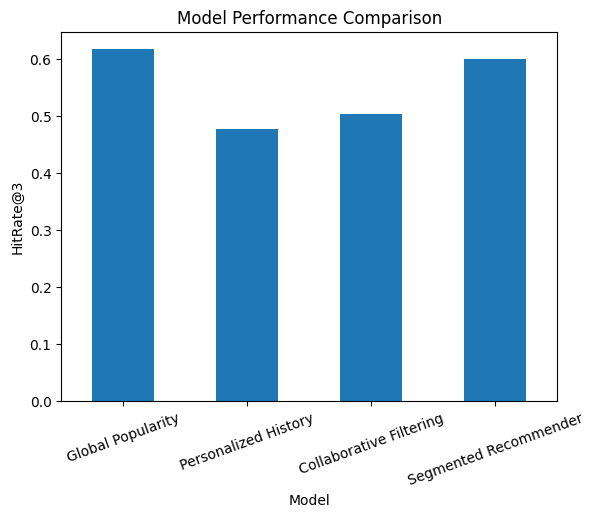

In [52]:
comparison = pd.DataFrame({
    "Model": [
        "Global Popularity",
        "Personalized History",
        "Collaborative Filtering",
        "Segmented Recommender"
    ],
    "HitRate@3": [
        hitrate_at_k,
        personal_hitrate_at_k,
        cf_hitrate_at_k,
        segmented_hitrate_at_k
    ]
})

comparison.plot(
    kind="bar",
    x="Model",
    y="HitRate@3",
    legend=False,
    title="Model Performance Comparison",
    ylabel="HitRate@3",
    rot=20
);

### Model 4 Segmented Conclusion

The segmented recommender applies different recommendation strategies depending on how much user history is available and how concentrated that history is.

This approach is more aligned with the actual structure of the dataset than forcing a single model across all users. Sparse and repeat users are handled with the strong popularity signal, while exploratory users are routed to a more personalized collaborative filtering model.

# Final Modeling Takeaway

The **global popularity model remained a strong benchmark** due to the extreme concentration of redemption activity among a small number of SKUs - primarily Nitro SKU.

More complex models such as collaborative filtering improved personalization for some users but did not meet the high baseline performance.

**The segmented recommender represents the most practical product-oriented extension**, as it applies different recommendation strategies depending on user behavior and data availability.

Future improvements would focus on **expanding the behavioral lookback window and incorporating richer user features** to improve personalization for exploratory users.